In [1]:
import glob
import os

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import librosa
import librosa.display

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# consts and functions

In [2]:
DIR_BASE = '/Users/calvinhinkle/Desktop/school/mines/2026/spring/adML/finalProj/Binary_Drone_Audio/'
DIR_DRONE = os.path.join(DIR_BASE, 'yes_drone')
DIR_UNKNOWN = os.path.join(DIR_BASE, 'unknown')

DURATION = 1.024  # sec
SR = 16000

LENGTH_N = int(SR * DURATION)

N_FFT = 1024
HOP_LENGTH = N_FFT // 4

TEST_FRAC = 0.2
RANDOM_SEED = 42

In [3]:
#audio processing
def fix_length(y, target_len):
    if len(y) > target_len:
        return y[:target_len]
    else:
        return np.pad(y, (0, target_len - len(y)))

def preprocess(path):
    y_raw, _ = librosa.load(path, mono=True, sr=SR)

    # normalize amplitude
    y_norm = librosa.util.normalize(y_raw)

    # force fixed duration
    y = fix_length(y_norm, LENGTH_N)

    return y

#feature extraction

def extract_features(y, sr=SR):

    features = []

    S = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH))

    #mfcc
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)

    features.extend(np.mean(mfcc, axis=1))
    features.extend(np.std(mfcc, axis=1))
    
    #time mfcc data
    delta_mfcc = librosa.feature.delta(mfcc)
    delta2_mfcc = librosa.feature.delta(mfcc, order=2)

    features.extend(np.mean(delta_mfcc, axis=1))
    features.extend(np.std(delta_mfcc, axis=1))

    features.extend(np.mean(delta2_mfcc, axis=1))
    features.extend(np.std(delta2_mfcc, axis=1))

    #spectral feats
    spec_centroid = librosa.feature.spectral_centroid(S=S, sr=sr)
    spec_bandwidth = librosa.feature.spectral_bandwidth(S=S, sr=sr)
    spec_rolloff = librosa.feature.spectral_rolloff(S=S, sr=sr)
    spec_contrast = librosa.feature.spectral_contrast(S=S, sr=sr)

    for f in [spec_centroid, spec_bandwidth, spec_rolloff]:
        features.append(np.mean(f))
        features.append(np.std(f))

    features.extend(np.mean(spec_contrast, axis=1))
    features.extend(np.std(spec_contrast, axis=1))

    #harmonic, percussive
    y_harm, y_perc = librosa.effects.hpss(y)
    features.append(np.sum(y_harm ** 2))
    #features.append(np.sum(y_perc ** 2))

    #zero crossing rate
    zcr = librosa.feature.zero_crossing_rate(y)
    features.append(np.mean(zcr))
    features.append(np.std(zcr))

    return np.array(features, dtype=np.float32)

#.wav to features
def wav_to_data(filepath):

    data = preprocess(filepath)

    if data.ndim > 1:
        data = data.mean(axis=1)

    features = extract_features(data)

    return features

def load_dataset(dir_drone, dir_unknown):
    X = []
    y = []

    # 0 = drone
    # 1 = unknown
    for label, folder in [(0, dir_drone), (1, dir_unknown)]:
        for filename in os.listdir(folder):
            if not filename.lower().endswith(".wav"):
                continue
            filepath = os.path.join(folder, filename)
            try:
                features = wav_to_data(filepath)
                X.append(features)
                y.append(label)
            except Exception as e:
                print(f"Skipping {filepath}: {e}")
    X = np.stack(X)
    y = np.array(y, dtype=np.int64)
    return X, y



# Load data, train/test split, model

In [4]:
X, y = load_dataset(
    dir_drone=DIR_DRONE,
    dir_unknown=DIR_UNKNOWN
)

print("Dataset shape:", X.shape)

Dataset shape: (11704, 143)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=TEST_FRAC, random_state=RANDOM_SEED, stratify=y)

model = Pipeline([
    ("scaler", StandardScaler()),

    ("classifier", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_SEED
    ))
])

In [32]:
'''
model = Pipeline([
    ("scaler", StandardScaler()),

    ("classifier", LogisticRegression(
    penalty="l1",
    solver="saga",
    max_iter=5000,
    class_weight="balanced",
    random_state=RANDOM_SEED
))
])'''

# Train

In [50]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_probs = model.predict_proba(X_test)[:, 0]

# Metrics

In [51]:
drone_true = (y_test == 0).astype(int)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),

    "balanced_accuracy": balanced_accuracy_score(
        y_test,
        y_pred
    ),

    "drone_precision": precision_score(
        y_test,
        y_pred,
        pos_label=0,
        zero_division=0
    ),

    "drone_recall": recall_score(
        y_test,
        y_pred,
        pos_label=0,
        zero_division=0
    ),

    "drone_f1": f1_score(
        y_test,
        y_pred,
        pos_label=0,
        zero_division=0
    ),

    "drone_pr_auc": average_precision_score(
        drone_true,
        y_probs
    ),

    "confusion_matrix": confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    )
}

In [52]:
print("\nmetrics")

for key, value in metrics.items():

    if key == "confusion_matrix":
        continue

    print(f"{key}: {value:.4f}")

print("\nConfusion Matrix:")
print(metrics["confusion_matrix"])

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


metrics
accuracy: 0.9586
balanced_accuracy: 0.9586
drone_precision: 0.7478
drone_recall: 0.9586
drone_f1: 0.8402
drone_pr_auc: 0.9533

Confusion Matrix:
[[ 255   11]
 [  86 1989]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.96      0.84       266
           1       0.99      0.96      0.98      2075

    accuracy                           0.96      2341
   macro avg       0.87      0.96      0.91      2341
weighted avg       0.97      0.96      0.96      2341



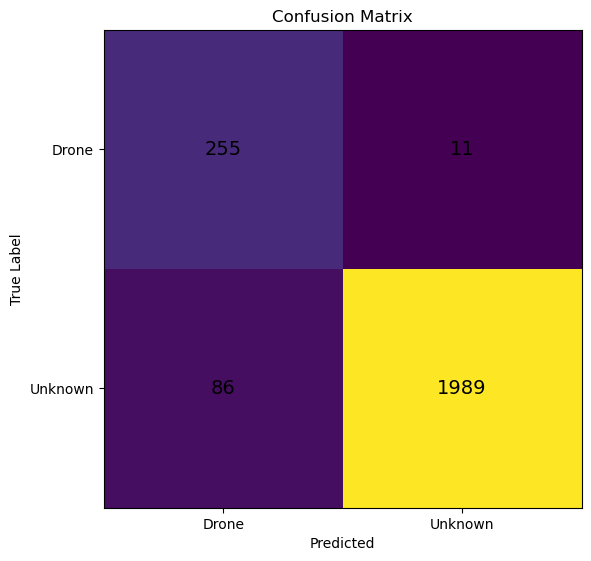

Num features: 143
Num coeffs:   143


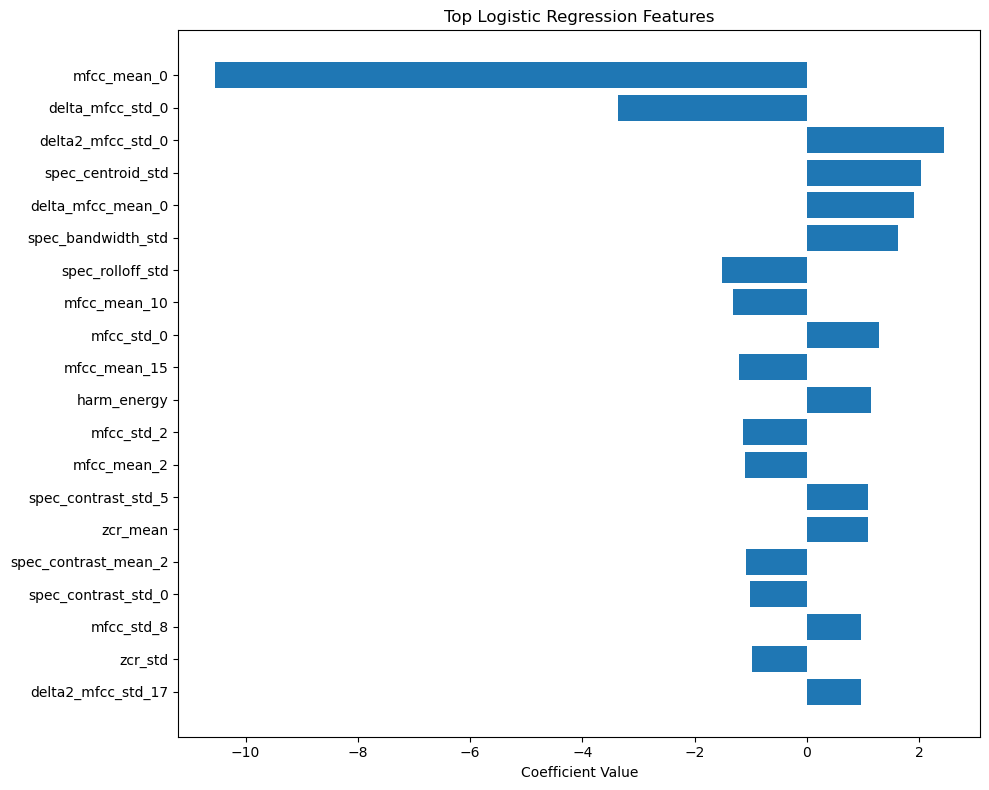

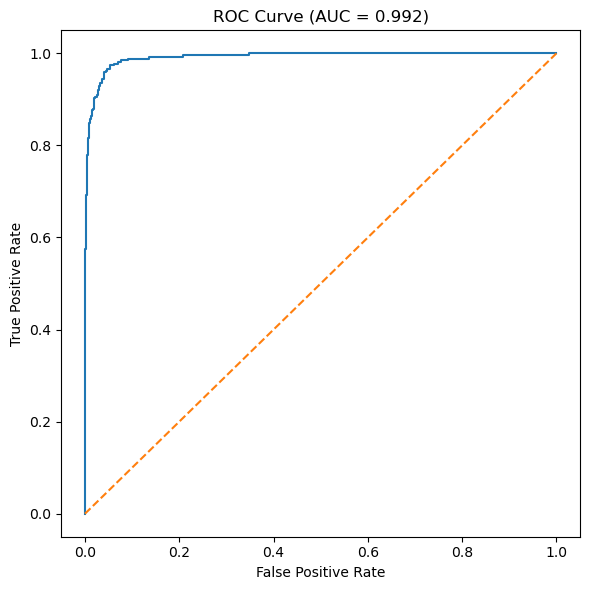

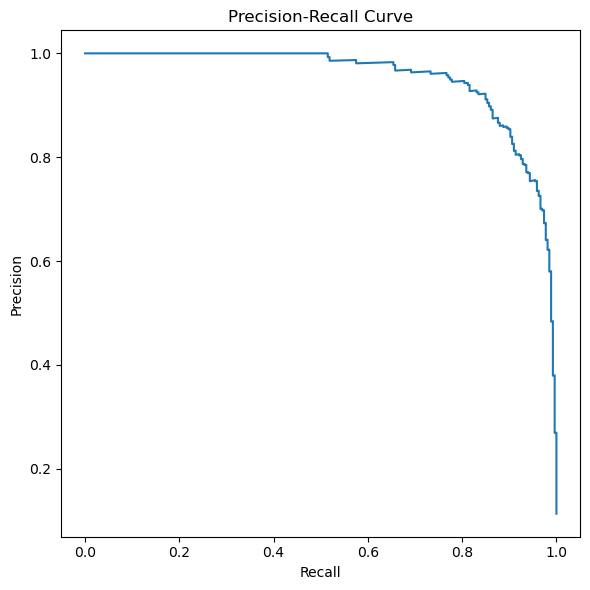

In [53]:
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve
)

cm = metrics["confusion_matrix"]

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cm)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Drone", "Unknown"])
ax.set_yticklabels(["Drone", "Unknown"])
ax.set_xlabel("Predicted")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]),
            ha="center", va="center", fontsize=14)
        
plt.tight_layout()
plt.show()



classifier = model.named_steps["classifier"]

coeffs = classifier.coef_[0]

feature_names = []

for i in range(20):
    feature_names.append(f"mfcc_mean_{i}")

for i in range(20):
    feature_names.append(f"mfcc_std_{i}")

for i in range(20):
    feature_names.append(f"delta_mfcc_mean_{i}")

for i in range(20):
    feature_names.append(f"delta_mfcc_std_{i}")

for i in range(20):
    feature_names.append(f"delta2_mfcc_mean_{i}")

for i in range(20):
    feature_names.append(f"delta2_mfcc_std_{i}")

feature_names += [
    "spec_centroid_mean",
    "spec_centroid_std",
    "spec_bandwidth_mean",
    "spec_bandwidth_std",
    "spec_rolloff_mean",
    "spec_rolloff_std",
]

for i in range(7):
    feature_names.append(f"spec_contrast_mean_{i}")

for i in range(7):
    feature_names.append(f"spec_contrast_std_{i}")

feature_names += ["harm_energy"]

feature_names += ["zcr_mean", "zcr_std"]

print("Num features:", len(feature_names))
print("Num coeffs:  ", len(coeffs))

importance = np.abs(coeffs)
top_n = 20
top_idx = np.argsort(importance)[-top_n:]
top_features = [feature_names[i] for i in top_idx]
top_values = coeffs[top_idx]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_features, top_values)
ax.set_title("Top Logistic Regression Features")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

drone_probs = model.predict_proba(X_test)[:, 0]
drone_true = (y_test == 0).astype(int)
fpr, tpr, _ = roc_curve(drone_true, drone_probs)
roc_auc = auc(fpr, tpr)
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(fpr, tpr)
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.tight_layout()
plt.show()


precision, recall, _ = precision_recall_curve(
    drone_true, drone_probs)

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(recall, precision)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

This is quite good, but with a high false positive rate. First, lets just look and see if changing the threshold works.

In [54]:
drone_probs = model.predict_proba(X_test)[:, 0]

threshold = 0.75

y_pred = (drone_probs > threshold).astype(int)

# class 0 = drone
# convert properly
y_pred = np.where(drone_probs > threshold, 0, 1)

In [55]:
drone_true = (y_test == 0).astype(int)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),

    "balanced_accuracy": balanced_accuracy_score(
        y_test,
        y_pred
    ),

    "drone_precision": precision_score(
        y_test,
        y_pred,
        pos_label=0,
        zero_division=0
    ),

    "drone_recall": recall_score(
        y_test,
        y_pred,
        pos_label=0,
        zero_division=0
    ),

    "drone_f1": f1_score(
        y_test,
        y_pred,
        pos_label=0,
        zero_division=0
    ),

    "drone_pr_auc": average_precision_score(
        drone_true,
        y_probs
    ),

    "confusion_matrix": confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    )
}

In [57]:
print("\n metrics")

for key, value in metrics.items():

    if key == "confusion_matrix":
        continue

    print(f"{key}: {value:.4f}")

print("\nConfusion Matrix:")
print(metrics["confusion_matrix"])

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


 metrics
accuracy: 0.9714
balanced_accuracy: 0.9396
drone_precision: 0.8566
drone_recall: 0.8985
drone_f1: 0.8771
drone_pr_auc: 0.9533

Confusion Matrix:
[[ 239   27]
 [  40 2035]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       266
           1       0.99      0.98      0.98      2075

    accuracy                           0.97      2341
   macro avg       0.92      0.94      0.93      2341
weighted avg       0.97      0.97      0.97      2341



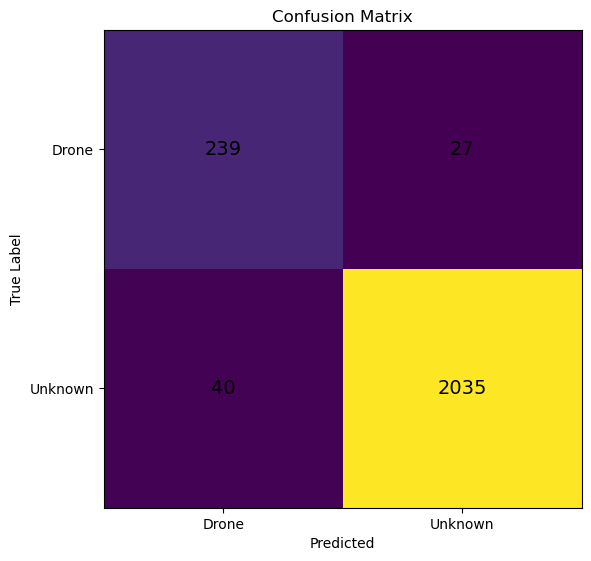

Num features: 143
Num coeffs:   143


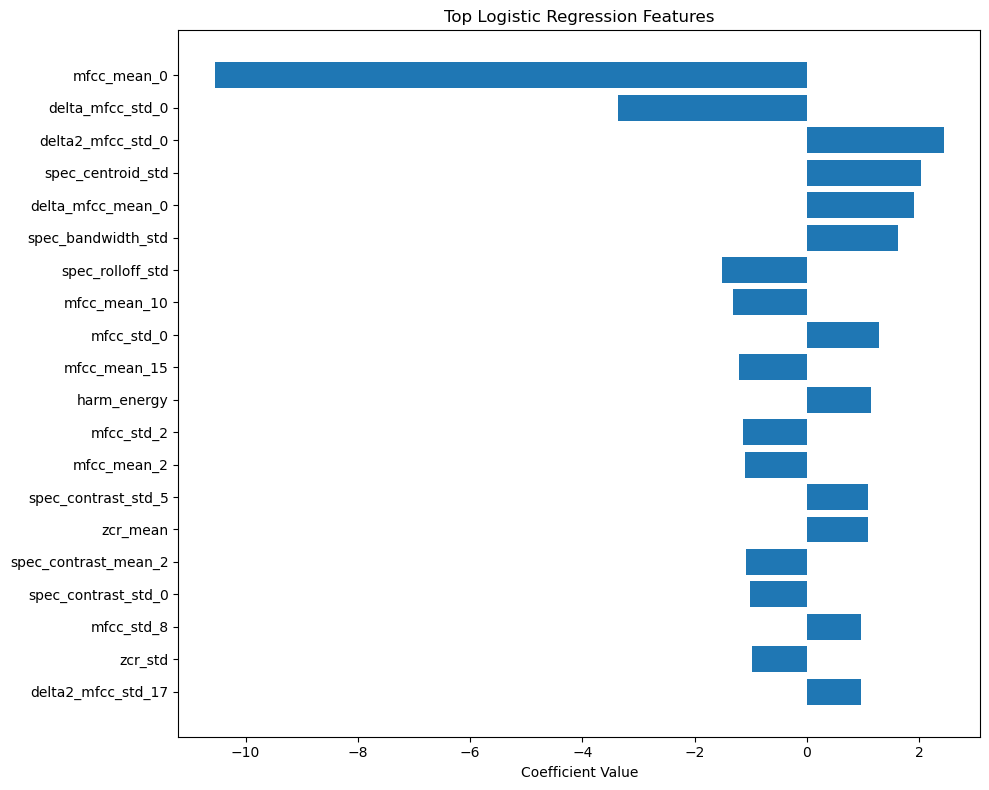

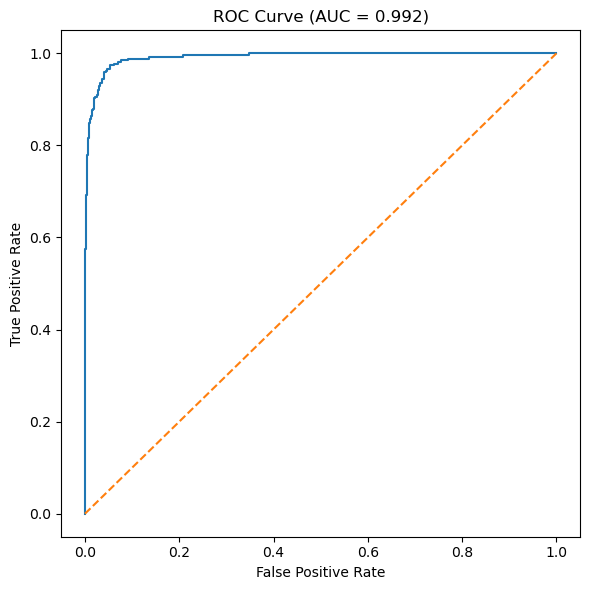

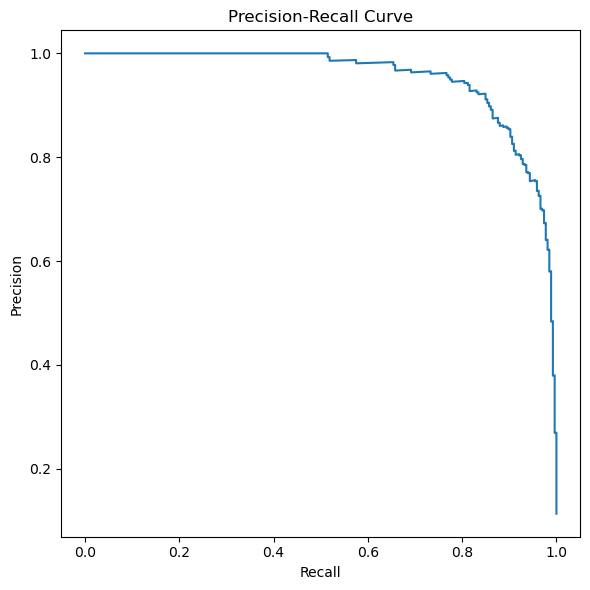

In [58]:
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve
)

cm = metrics["confusion_matrix"]

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cm)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Drone", "Unknown"])
ax.set_yticklabels(["Drone", "Unknown"])
ax.set_xlabel("Predicted")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]),
            ha="center", va="center", fontsize=14)
        
plt.tight_layout()
plt.show()



classifier = model.named_steps["classifier"]

coeffs = classifier.coef_[0]

feature_names = []

for i in range(20):
    feature_names.append(f"mfcc_mean_{i}")

for i in range(20):
    feature_names.append(f"mfcc_std_{i}")

for i in range(20):
    feature_names.append(f"delta_mfcc_mean_{i}")

for i in range(20):
    feature_names.append(f"delta_mfcc_std_{i}")

for i in range(20):
    feature_names.append(f"delta2_mfcc_mean_{i}")

for i in range(20):
    feature_names.append(f"delta2_mfcc_std_{i}")

feature_names += [
    "spec_centroid_mean",
    "spec_centroid_std",
    "spec_bandwidth_mean",
    "spec_bandwidth_std",
    "spec_rolloff_mean",
    "spec_rolloff_std",
]

for i in range(7):
    feature_names.append(f"spec_contrast_mean_{i}")

for i in range(7):
    feature_names.append(f"spec_contrast_std_{i}")

feature_names += ["harm_energy"]

feature_names += ["zcr_mean", "zcr_std"]

print("Num features:", len(feature_names))
print("Num coeffs:  ", len(coeffs))

importance = np.abs(coeffs)
top_n = 20
top_idx = np.argsort(importance)[-top_n:]
top_features = [feature_names[i] for i in top_idx]
top_values = coeffs[top_idx]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_features, top_values)
ax.set_title("Top Logistic Regression Features")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

drone_probs = model.predict_proba(X_test)[:, 0]
drone_true = (y_test == 0).astype(int)
fpr, tpr, _ = roc_curve(drone_true, drone_probs)
roc_auc = auc(fpr, tpr)
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(fpr, tpr)
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.tight_layout()
plt.show()


precision, recall, _ = precision_recall_curve(
    drone_true, drone_probs)

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(recall, precision)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

# SVM

we can use the same X, y data

## imports


In [72]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    auc,
    precision_recall_curve,
)

## model

In [115]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),

    ("classifier", LinearSVC(
        C=35,
        class_weight="balanced",
        max_iter=50000,
        dual=False,
        random_state=RANDOM_SEED
    ))
])

In [116]:
svm_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LinearSVC(C=35, class_weight='balanced', dual=False,
                           max_iter=50000, random_state=42))])

In [122]:
#y_pred = svm_model.predict(X_test)

#soft
scores = svm_model.decision_function(X_test)

drone_scores = -scores

threshold = 0.513

y_pred = np.where(
    drone_scores > threshold,
    0,
    1
)

In [123]:
decision_scores = svm_model.decision_function(X_test)

# drone = class 0
drone_scores = -decision_scores

drone_true = (y_test == 0).astype(int)

## metrics

In [124]:
svm_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),

    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),

    "drone_precision": precision_score(y_test, y_pred, pos_label=0, zero_division=0),

    "drone_recall": recall_score(y_test, y_pred, pos_label=0, zero_division=0),

    "drone_f1": f1_score(y_test, y_pred, pos_label=0, zero_division=0),

    "drone_pr_auc": average_precision_score(drone_true, drone_scores),

    "confusion_matrix": confusion_matrix(y_test, y_pred, labels=[0, 1])
}

In [125]:
print("\nmetrics")

for key, value in svm_metrics.items():

    if key == "confusion_matrix":
        continue

    print(f"{key}: {value:.4f}")

print("\nConfusion Matrix:")
print(svm_metrics["confusion_matrix"])

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


metrics
accuracy: 0.9705
balanced_accuracy: 0.9277
drone_precision: 0.8689
drone_recall: 0.8722
drone_f1: 0.8705
drone_pr_auc: 0.9513

Confusion Matrix:
[[ 232   34]
 [  35 2040]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       266
           1       0.98      0.98      0.98      2075

    accuracy                           0.97      2341
   macro avg       0.93      0.93      0.93      2341
weighted avg       0.97      0.97      0.97      2341



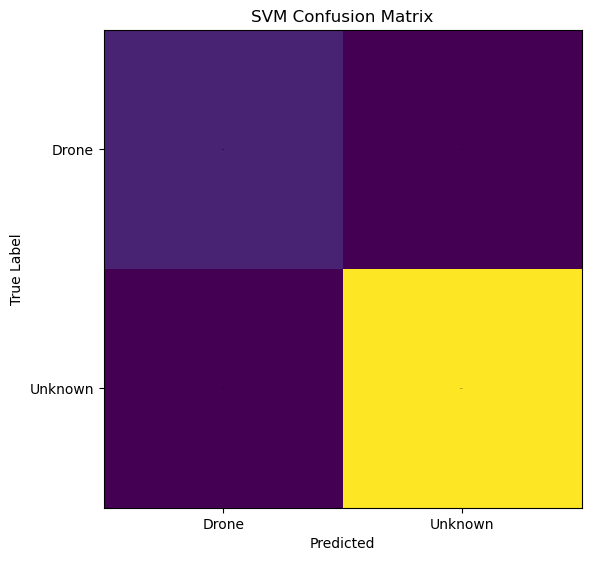

In [126]:
cm = svm_metrics["confusion_matrix"]
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Drone", "Unknown"])
ax.set_yticklabels(["Drone", "Unknown"])
ax.set_xlabel("Predicted")
ax.set_ylabel("True Label")
ax.set_title("SVM Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]),
                ha="center", va="center", fontsize=1)
plt.tight_layout()
plt.show()

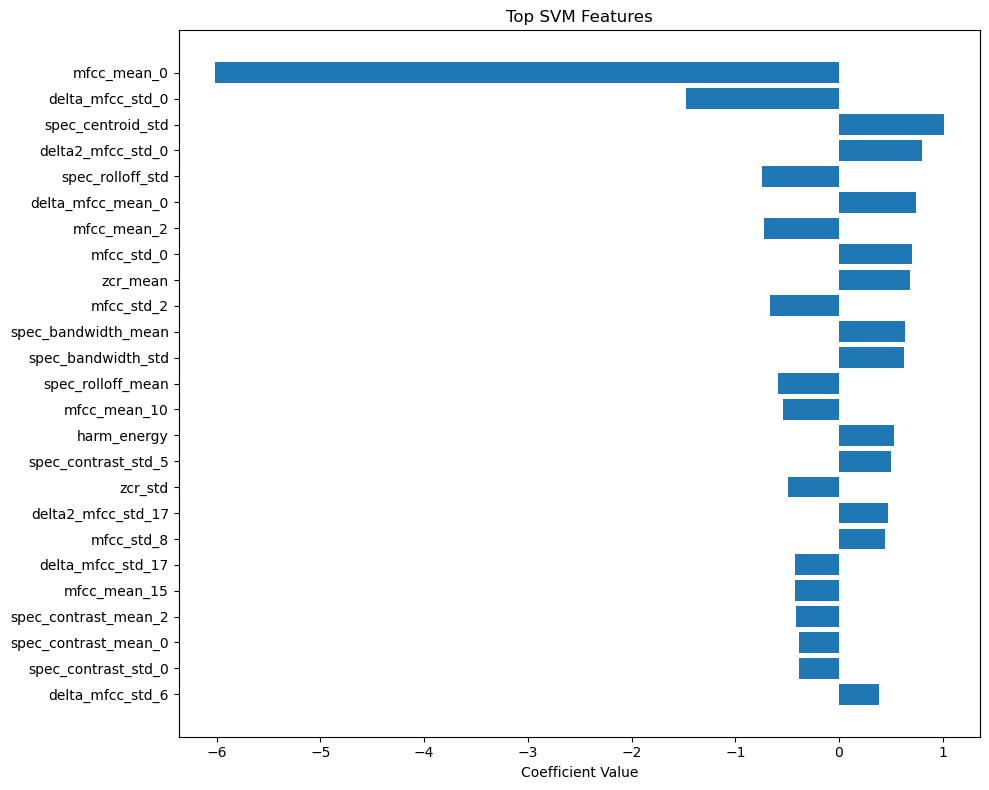

In [127]:
classifier = svm_model.named_steps["classifier"]

coeffs = classifier.coef_[0]

importance = np.abs(coeffs)

top_n = 25

top_idx = np.argsort(importance)[-top_n:][::-1]

top_features = [feature_names[i] for i in top_idx]
top_values = coeffs[top_idx]

fig, ax = plt.subplots(figsize=(10, 8))

y_pos = np.arange(len(top_features))

ax.barh(y_pos, top_values)

ax.set_yticks(y_pos)
ax.set_yticklabels(top_features)

ax.invert_yaxis()

ax.set_title("Top SVM Features")
ax.set_xlabel("Coefficient Value")

plt.tight_layout()
plt.show()

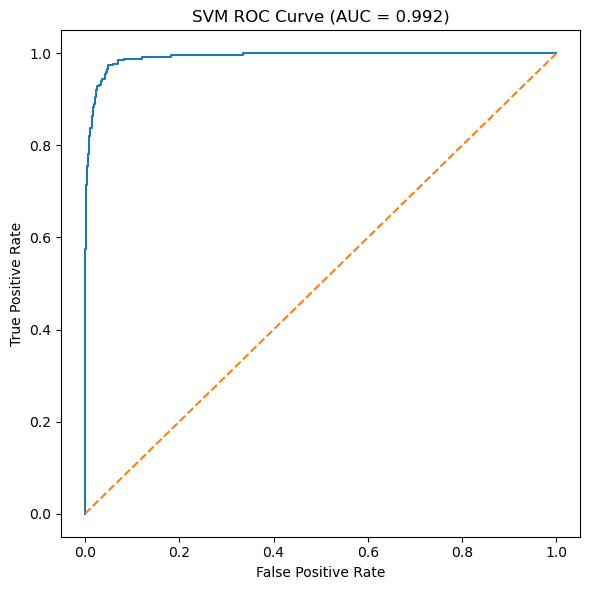

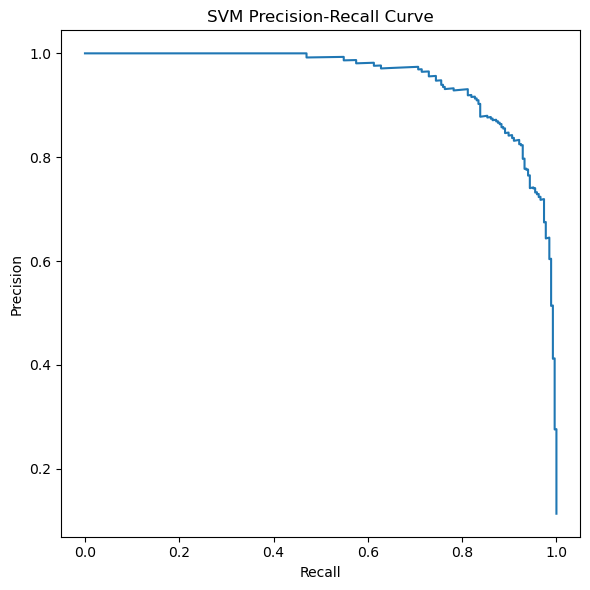

In [128]:

fpr, tpr, _ = roc_curve(drone_true, drone_scores)

roc_auc = auc(fpr, tpr)
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(fpr, tpr)
ax.plot([0, 1], [0, 1], linestyle="--")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"SVM ROC Curve (AUC = {roc_auc:.3f})")
plt.tight_layout()
plt.show()


precision, recall, _ = precision_recall_curve(drone_true, drone_scores)
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(recall, precision)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("SVM Precision-Recall Curve")
plt.tight_layout()
plt.show()

## hyperparpameter seelction

In [108]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
)

# ============================================================
# PIPELINE
# ============================================================

pipeline = Pipeline([
    ("scaler", StandardScaler()),

    ("classifier", LinearSVC(
        class_weight="balanced",
        dual=False,
        max_iter=50000,
        random_state=RANDOM_SEED
    ))
])

# ============================================================
# PARAMETER GRID
# ============================================================

param_grid = {
    "classifier__C": [
        0.001,
        0.01,
        0.1,
        1,
        10,
        34,
        35,
        36,
        50,
        100
    ]
}

# ============================================================
# GRID SEARCH
# ============================================================

grid_search = GridSearchCV(
    estimator=pipeline,

    param_grid=param_grid,

    scoring="f1_macro",

    cv=5,

    verbose=2,

    n_jobs=-1
)

# ============================================================
# TRAIN
# ============================================================

grid_search.fit(X_train, y_train)

# ============================================================
# BEST MODEL
# ============================================================

best_model = grid_search.best_estimator_

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest CV Score:")
print(grid_search.best_score_)

# ============================================================
# TEST SET EVALUATION
# ============================================================

y_pred = best_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

drone_f1 = f1_score(
    y_test,
    y_pred,
    pos_label=0
)

print(f"\nDrone F1: {drone_f1:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters:
{'classifier__C': 35}

Best CV Score:
0.9059850229390485

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.94      0.84       266
           1       0.99      0.96      0.98      2075

    accuracy                           0.96      2341
   macro avg       0.87      0.95      0.91      2341
weighted avg       0.96      0.96      0.96      2341


Confusion Matrix:
[[ 251   15]
 [  84 1991]]

Drone F1: 0.8353


### theshold


In [121]:
thresholds = np.linspace(
    drone_scores.min(),
    drone_scores.max(),
    100
)

best_f1 = 0
best_thresh = 0

for thresh in thresholds:

    y_pred_thresh = np.where(
        drone_scores > thresh,
        0,
        1
    )

    f1 = f1_score(
        y_test,
        y_pred_thresh,
        pos_label=0
    )

    precision = precision_score(
        y_test,
        y_pred_thresh,
        pos_label=0
    )

    recall = recall_score(
        y_test,
        y_pred_thresh,
        pos_label=0
    )

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

    print(
        f"Thresh={thresh:.3f} | "
        f"P={precision:.3f} | "
        f"R={recall:.3f} | "
        f"F1={f1:.3f}"
    )

print("\nBest threshold:", best_thresh)
print("Best F1:", best_f1)

Thresh=-24.544 | P=0.125 | R=1.000 | F1=0.223
Thresh=-24.231 | P=0.125 | R=1.000 | F1=0.223
Thresh=-23.918 | P=0.125 | R=1.000 | F1=0.223
Thresh=-23.604 | P=0.125 | R=1.000 | F1=0.223
Thresh=-23.291 | P=0.125 | R=1.000 | F1=0.223
Thresh=-22.978 | P=0.125 | R=1.000 | F1=0.223
Thresh=-22.665 | P=0.125 | R=1.000 | F1=0.223
Thresh=-22.352 | P=0.125 | R=1.000 | F1=0.223
Thresh=-22.038 | P=0.125 | R=1.000 | F1=0.223
Thresh=-21.725 | P=0.125 | R=1.000 | F1=0.223
Thresh=-21.412 | P=0.125 | R=1.000 | F1=0.223
Thresh=-21.099 | P=0.125 | R=1.000 | F1=0.223
Thresh=-20.786 | P=0.125 | R=1.000 | F1=0.223
Thresh=-20.472 | P=0.125 | R=1.000 | F1=0.223
Thresh=-20.159 | P=0.125 | R=1.000 | F1=0.223
Thresh=-19.846 | P=0.125 | R=1.000 | F1=0.223
Thresh=-19.533 | P=0.125 | R=1.000 | F1=0.223
Thresh=-19.219 | P=0.125 | R=1.000 | F1=0.223
Thresh=-18.906 | P=0.125 | R=1.000 | F1=0.223
Thresh=-18.593 | P=0.125 | R=1.000 | F1=0.223
Thresh=-18.280 | P=0.125 | R=1.000 | F1=0.223
Thresh=-17.967 | P=0.125 | R=1.000

/Users/calvinhinkle/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


[CV] END ................................classifier__C=0.001; total time=   0.2s
[CV] END ..................................classifier__C=0.1; total time=   0.2s
[CV] END ...................................classifier__C=10; total time=   0.2s
[CV] END .................................classifier__C=0.01; total time=   0.2s
[CV] END ....................................classifier__C=1; total time=   0.2s
[CV] END ..................................classifier__C=100; total time=   0.2s
[CV] END .................................classifier__C=0.01; total time=   0.2s
[CV] END ....................................classifier__C=1; total time=   0.2s
[CV] END ..................................classifier__C=500; total time=   0.2s
[CV] END ..................................classifier__C=500; total time=   0.2s
[CV] END ................................classifier__C=0.001; total time=   0.2s
[CV] END ..................................classifier__C=0.1; total time=   0.2s
[CV] END ...................